#### Time Wrapper
--- 

The function to keep track of process_time in millisecond.

In [24]:
# use real-time to measure the time to run a function
from time import process_time_ns


def time_operation(func):
    def wrapper(*args, **kwargs):
        start = process_time_ns()
        time_result = func(*args, **kwargs)
        end = process_time_ns()
        return time_result, (end - start) / 10**6  # milliseconds

    return wrapper

In [25]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold,  cross_validate, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from pathlib import Path

In [26]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")  # seaborn's FutureWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)  # sklearn's ConvergenceWarning

## Multi-stage Pipeline
---

This code focuses on creating a pipe-line from ETL, Modeling (Training,  Validation), Result, Data-Visualization, etc.

#### Stage 1: Preparation for the Modeling
---
We need a few custom classes to handle the specific logic from our eda.ipynb, such as the "chaos" null replacement and the specific string mappings for car features.

1. CarDataClearner class
2. CarOrdinalEncoder class
3. Create a preprocessor pipeline (standalone helper function) that handles everything up to the scaling
4. Create a Cross-Evaluation Engine (standalone helper function) to evaluate all models

In [27]:
# 1. Cleaner for null flavors and string mappings (Steps 5 & 6)
class CarDataCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.null_flavors = {"", "null", "NaN", "NULL", "none", "None"}
        self.mapping = {"5more": "6", "more": "6"}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # 1. Ensure we work on a DataFrame (not numpy array)
        X = pd.DataFrame(X).copy()

        # 2. Globally replace chaos nulls
        X = X.replace(self.null_flavors, np.nan)

        # 3. Specific strings replacements for doors/seats
        if "doors" in X.columns:
            X["doors"] = X["doors"].replace("5more", "6")

        if "seats" in X.columns:
            X["seats"] = X["seats"].replace("more", "6")

        return X

In [28]:
# 2. Imputer for missing values
class CarDataImputer(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.int_cols = ["doors", "seats"]
        self.cat_cols = ["price", "maintenance", "safety", "storage"]
        # Standard ColumnTransformer logic
        self.ct = ColumnTransformer(transformers=[
            ('median_imputer', SimpleImputer(strategy='median'), self.int_cols),
            ('mode_imputer', SimpleImputer(strategy='most_frequent'), self.cat_cols,),
        ], remainder='drop')

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X, columns=self.feature_names).copy()
        self.ct.fit(X_df)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names)
        # Note: ColumnTransformer reorders columns (int_cols first, then cat_cols)
        # We must track this new order for the next step in the pipeline
        transformed_data = self.ct.transform(X_df)

        # FIX: Dynamically determine output columns
        # ColumnTransformer places transformed columns FIRST, then 'passthrough' columns
        # If there's a 7th column, we need to account for it or drop it
        if transformed_data.shape[1] == 7:
            # If you have an extra column (like a label or ID), we name it 'extra'
            # to avoid the shape mismatch error
            self.output_features_ = self.int_cols + self.cat_cols + ['unknown_feature']
        else:
            self.output_features_ = self.int_cols + self.cat_cols
            
        return pd.DataFrame(transformed_data, columns=self.output_features_)

In [29]:
# 3. Ordinal Mapping for Car Features
class CarDataEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, feature_names):
        self.feature_names = feature_names
        # Define the columns and their specific logical order
        self.features_map = {
            "price": ["low", "med", "high", "vhigh"],
            "maintenance": ["low", "med", "high", "vhigh"],
            "storage": ["small", "med", "big"],
            "safety": ["low", "med", "high"],
        }

        # Initialize the encoder with your specific categories
        self.cat_cols = list(self.features_map.keys())
        self.category_lists = list(self.features_map.values())
        self.encoder = OrdinalEncoder(categories=self.category_lists, handle_unknown="use_encoded_value", unknown_value=-1)

    def fit(self, X, y=None):
        # Ensure X is a DataFrame to select columns by name
        X_df = pd.DataFrame(X, columns=self.feature_names).copy()
        # Fit the encoder only on the categorical columns
        self.encoder.fit(X_df[self.cat_cols])
        return self

    def transform(self, X):
        # Create a copy to avoid modifying the original data
        X_df = pd.DataFrame(X).copy()

        # 1. Transform the categorical columns using the fitted encoder
        X_df[self.cat_cols] = self.encoder.transform(X_df[self.cat_cols])

        # 2. Final numeric check for doors/seats (Step 7 & 11)
        # Since '5more' was changed to '6' in the cleaner, we convert to numeric here
        for col in ["doors", "seats"]:
            X_df[col] = pd.to_numeric(X_df[col], errors="coerce")
        return X_df

In [30]:
def evaluate_all_models_with_pipeline(models_dict, X, y, cv_strategy, preprocessor):
    """Runs repeated cross-validation where each fold includes preprocessing."""
    print("Sub-Phase: Executing Multi-Algorithm Comparison with Pipeline...")

    custom_scoring = {
        "accuracy": make_scorer(accuracy_score),
        "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
        "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
        "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    }

    all_results = {}

    for name, model in models_dict.items():
        print(f"   Testing: {name}...")

        # Create a full pipeline that includes the preprocessor AND the specific model
        full_job_pipeline = Pipeline(steps=[("preprocess", preprocessor), ("classifier", model)])

        timed_cv = time_operation(cross_validate)

        # We pass the RAW X here because the pipeline handles the cleaning/scaling internally
        cv_results, duration = timed_cv(full_job_pipeline, X, y, cv=cv_strategy, scoring=custom_scoring, n_jobs=-1)

        all_results[name] = {
            "metrics": {
                "f1": {
                    "mean": cv_results["test_f1_macro"].mean(), 
                    "std": cv_results["test_f1_macro"].std()
                },
                "accuracy": {
                    "mean": cv_results["test_accuracy"].mean(), 
                    "std": cv_results["test_accuracy"].std()
                },
                "precision": {
                    "mean": cv_results["test_precision_macro"].mean(),
                    "std": cv_results["test_precision_macro"].std(),
                },
                "recall": {
                    "mean": cv_results["test_recall_macro"].mean(),
                    "std": cv_results["test_recall_macro"].std(),
                },
            },
            "time": duration,
            "model_pipeline": full_job_pipeline,  # Stores the pipeline structure
            "cv_results": cv_results,  # Stores detailed CV results
        }

    return all_results

In [31]:
# preprocessor pipeline
def create_preprocessor_pipeline(original_feature_names: list[str]) -> Pipeline:
    imputed_cols = ["doors", "seats", "price", "maintenance", "safety", "storage"]
    
    return Pipeline(
    steps=[
        ("cleaner", CarDataCleaner(feature_names=original_feature_names)),
        ("imputer", CarDataImputer(feature_names=original_feature_names)),
        ("encoder", CarDataEncoder(feature_names=original_feature_names)),
        ("scaler", MinMaxScaler()),
    ]
)

## Stage 2: Actual Application of the technique

#### 2.1 Load the data

In [32]:
data_path = Path().cwd().parent / "data" / "car.csv"
df = pd.read_csv(data_path)

df.shape
df.info()
feature_names = df.columns.tolist()
print(f"Feature Names: {feature_names}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   price        1728 non-null   object
 1   maintenance  1728 non-null   object
 2   doors        1728 non-null   object
 3   seats        1728 non-null   object
 4   storage      1728 non-null   object
 5   safety       1728 non-null   object
 6   shouldBuy    1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
Feature Names: ['price', 'maintenance', 'doors', 'seats', 'storage', 'safety', 'shouldBuy']


#### 2.2. Create features matrix (X), and Label vector (Y)

In [33]:
X = df.drop(columns=["shouldBuy"])
y = df["shouldBuy"]


#### 2.3 2. The 80/10/10 Stratified Split
---
This matches your Stage-1 (10% Vault ~ Test Data) and Stage-2 (Repeated Stratified K-Fold for Training with Cross-Validation).

In [34]:
# STAGE 1: Extract 10% for the 'Vault' (Testing)
# This results in X_vault (~173 rows) and X_dev (~1555 rows)
X_dev, X_vault, y_dev, y_vault = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)


le = LabelEncoder()
y_dev_encoded = le.fit_transform(y_dev)

# STAGE 2: Define the Cross-Validation Engine (Repeated Stratified K-Fold)
# 9 splits on 90% of data creates ~10% validation chunks (80/10/10 logic)
rskf = RepeatedStratifiedKFold(n_splits=9, n_repeats=10, random_state=42)

In [35]:
prepreocessor_pipeline = create_preprocessor_pipeline(feature_names)

#### 2.3. Master Execution Loop
---
Now, use the evaluate_all_models_with_pipeline function. This will pass each model through your preprocessor (Cleaner -> Imputer -> Encoder -> Scaler) for all 90 folds.

#### 2.3.1 Kind best KNN first

In [36]:
# 1. Create a dictionary of 20 KNN models
knn_tuning_dict = {f"KNN_K{k}": KNeighborsClassifier(n_neighbors=k) for k in range(1, 21)}

# CAPTURE the output into tuning_results
tuning_results = evaluate_all_models_with_pipeline(
    models_dict=knn_tuning_dict,
    X=X_dev,
    y=y_dev,
    cv_strategy=rskf, 
    preprocessor=prepreocessor_pipeline
)

# List to store flattened data
flattened_data = []

for model_name, results in tuning_results.items():
    # Extract K from the name (e.g., "KNN_K3" -> 3)
    k_val = int(model_name.split('_K')[-1])
    
    row = {
        'K': k_val,
        'f1_mean': results['metrics']['f1']['mean'],
        'f1_std': results['metrics']['f1']['std'],
        'accuracy_mean': results['metrics']['accuracy']['mean'],
        'precision_mean': results['metrics']['precision']['mean'],
        'recall_mean': results['metrics']['recall']['mean'],
        'time_sec': results['time']
    }
    
    # Calculate Stability Metric (Coefficient of Variation)
    # Lower is better for stability
    row['f1_cv'] = (row['f1_std'] / row['f1_mean']) * 100
    
    flattened_data.append(row)

# Create DataFrame and sort by K
df_tuning = pd.DataFrame(flattened_data).sort_values(by='K').reset_index(drop=True)

# Highlight the best K
best_k = df_tuning.loc[df_tuning['f1_mean'].idxmax(), 'K']
print(f"Optimal K identified: {best_k}")
display(df_tuning.sort_values(by='f1_mean', ascending=False))

Sub-Phase: Executing Multi-Algorithm Comparison with Pipeline...
   Testing: KNN_K1...


   Testing: KNN_K2...
   Testing: KNN_K3...
   Testing: KNN_K4...
   Testing: KNN_K5...
   Testing: KNN_K6...
   Testing: KNN_K7...
   Testing: KNN_K8...
   Testing: KNN_K9...
   Testing: KNN_K10...
   Testing: KNN_K11...
   Testing: KNN_K12...
   Testing: KNN_K13...
   Testing: KNN_K14...
   Testing: KNN_K15...
   Testing: KNN_K16...
   Testing: KNN_K17...
   Testing: KNN_K18...
   Testing: KNN_K19...
   Testing: KNN_K20...
Optimal K identified: 3


,K,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean,time_sec,f1_cv
2,3,0.824993,0.050635,0.927204,0.862103,0.815502,868.055469,6.137622
10,11,0.819182,0.056718,0.942774,0.906058,0.784178,725.015036,6.923771
14,15,0.818926,0.057099,0.943802,0.904620,0.784973,823.452889,6.972461
0,1,0.817527,0.051597,0.914406,0.819466,0.827819,829.261889,6.311376
16,17,0.815519,0.059394,0.942836,0.901566,0.781658,811.151180,7.282926
12,13,0.814967,0.056068,0.944185,0.905961,0.780212,561.272434,6.879797
18,19,0.811954,0.058723,0.942386,0.905847,0.775577,893.036279,7.232333
13,14,0.810956,0.059073,0.940970,0.899814,0.778012,783.643949,7.284389
15,16,0.809777,0.059384,0.940073,0.899313,0.776254,801.488601,7.333397
11,12,0.808877,0.057216,0.939746,0.908474,0.773953,793.001554,7.073560


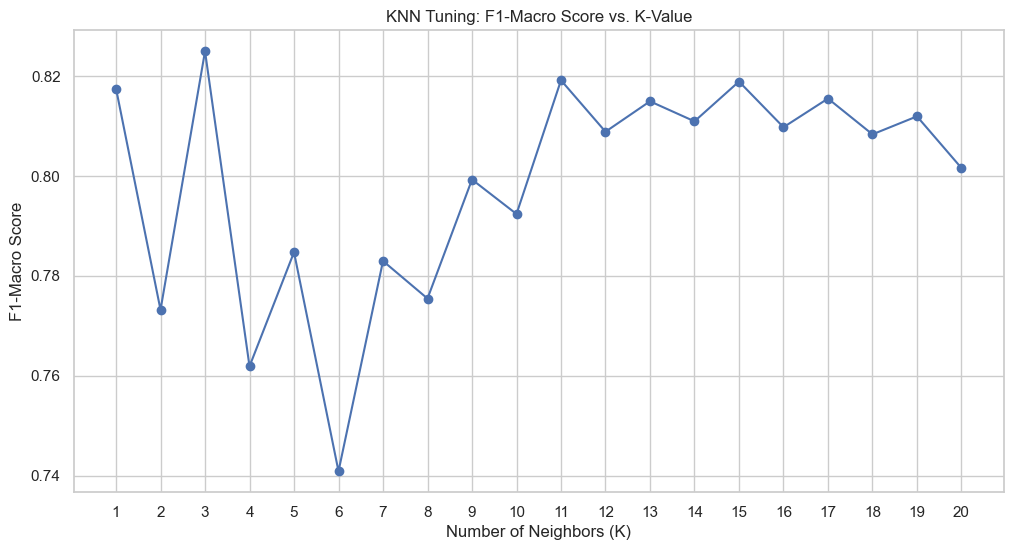

<Figure size 640x480 with 0 Axes>

In [37]:
# Visualize the elbow
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_tuning['K'], df_tuning['f1_mean'], marker='o', linestyle='-', color='b')
plt.title('KNN Tuning: F1-Macro Score vs. K-Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1-Macro Score')
plt.grid(True)
plt.xticks(range(1, 21))
plt.show()

save_path = Path().cwd().parent / "results" / 'knn_tuning_elbow_plot.png'
plt.savefig(save_path)

#### 2.3.2 All models training / validation

In [38]:
# 1. Update the best_k variable based on your plot
best_k = 3

# 2. Define the Final Master Model Suite
# Using the specific architectures and class_weights we discussed
model_suite = {
    "NaiveBayes": GaussianNB(),
    f"KNN_(K={best_k})": KNeighborsClassifier(n_neighbors=best_k),
    "SVM_Linear": SVC(kernel="linear", class_weight="balanced", probability=True),
    "SVM_RBF": SVC(kernel="rbf", class_weight="balanced", probability=True),
    "RandomForest": RandomForestClassifier(class_weight="balanced", max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=42),
    "ANN": MLPClassifier(
        hidden_layer_sizes=(12, 8),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=42
    ),
}

# 3. Run the Final Multi-Algorithm Comparison
# This will use your i9 processor to run 90 folds for each model
master_results = evaluate_all_models_with_pipeline(
    models_dict=model_suite,
    X=X_dev,
    y=y_dev_encoded,    # use encoded labels here
    cv_strategy=rskf, 
    preprocessor=prepreocessor_pipeline
)

Sub-Phase: Executing Multi-Algorithm Comparison with Pipeline...
   Testing: NaiveBayes...
   Testing: KNN_(K=3)...
   Testing: SVM_Linear...
   Testing: SVM_RBF...
   Testing: RandomForest...
   Testing: XGBoost...
   Testing: ANN...


#### 2.3.3 Analysis of Results (Training)

In [39]:
# 1. Initialize a list to store flattened data
comparison_data = []

for model_name, info in master_results.items():
    # Extract metrics for the final comparison table
    row = {
        "model": model_name,
        "f1_mean": info['metrics']['f1']['mean'],
        "f1_std": info['metrics']['f1']['std'],
        "accuracy_mean": info['metrics']['accuracy']['mean'],
        "precision_mean": info['metrics']['precision']['mean'],
        "recall_mean": info['metrics']['recall']['mean'],
        "time_ms": info['time']
    }
    
    # Calculate a Stability Score (Coefficient of Variation)
    # Lower value means more consistent performance across 90 folds
    row['stability_cv'] = (row['f1_std'] / row['f1_mean']) * 100
    
    comparison_data.append(row)

# 2. Create the DataFrame and sort by F1 Score (Primary Metric)
df_comparison = pd.DataFrame(comparison_data).sort_values(by="f1_mean", ascending=False).reset_index(drop=True)

# 3. Display the final leaderboard
print("Final Model Comparison Leaderboard:")
display(df_comparison)

Final Model Comparison Leaderboard:


,model,f1_mean,f1_std,accuracy_mean,precision_mean,recall_mean,time_ms,stability_cv
0,XGBoost,0.977050,0.023709,0.992541,0.979691,0.976994,985.592696,2.426578
1,RandomForest,0.941196,0.036243,0.974598,0.938184,0.950724,875.084718,3.850787
2,ANN,0.930910,0.038028,0.962316,0.934813,0.932839,1046.687494,4.085001
3,SVM_RBF,0.910321,0.030453,0.927015,0.880001,0.954990,836.247797,3.345349
4,KNN_(K=3),0.824993,0.050635,0.927204,0.862103,0.815502,830.546225,6.137622
5,SVM_Linear,0.714004,0.043026,0.787281,0.654203,0.847881,836.117641,6.025961
6,NaiveBayes,0.431390,0.054413,0.695508,0.543177,0.561748,1405.122748,12.613457


#### Save our trained models
---
w/ pipeline that can be used elsewhere


In [40]:
import joblib
from pathlib import Path

# 1. Setup paths
results_dir = Path.cwd().parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

print("📦 Exporting all trained pipelines...")

for name, info in master_results.items():
    # Retrieve the fitted pipeline
    pipeline = info['model_pipeline']
    
    # CRITICAL STEP: Fit the model before saving
    print(f"Fitting {name}...")
    pipeline.fit(X_dev, y_dev_encoded)

    # Sanitize the model name for the file system (remove spaces/special chars)
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    model_filename = f"pipeline_{clean_name}.joblib"
    save_path = results_dir / model_filename
    
    # Export the pipeline
    joblib.dump(pipeline, save_path)
    print(f"   Successfully saved: {model_filename}")

# 2. Save the LabelEncoder 'le' separately 
# This is crucial for decoding predictions (0 -> 'unacc') in other files
le_path = results_dir / "pipeline_label_encoder.joblib"
joblib.dump(le, le_path)

print(f"\n✅ All {len(master_results)} models and the LabelEncoder have been saved to: {results_dir}")

📦 Exporting all trained pipelines...
Fitting NaiveBayes...
   Successfully saved: pipeline_NaiveBayes.joblib
Fitting KNN_(K=3)...
   Successfully saved: pipeline_KNN_K3.joblib
Fitting SVM_Linear...
   Successfully saved: pipeline_SVM_Linear.joblib
Fitting SVM_RBF...
   Successfully saved: pipeline_SVM_RBF.joblib
Fitting RandomForest...
   Successfully saved: pipeline_RandomForest.joblib
Fitting XGBoost...
   Successfully saved: pipeline_XGBoost.joblib
Fitting ANN...
   Successfully saved: pipeline_ANN.joblib

✅ All 7 models and the LabelEncoder have been saved to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results


## Stage 3: Data Visualization


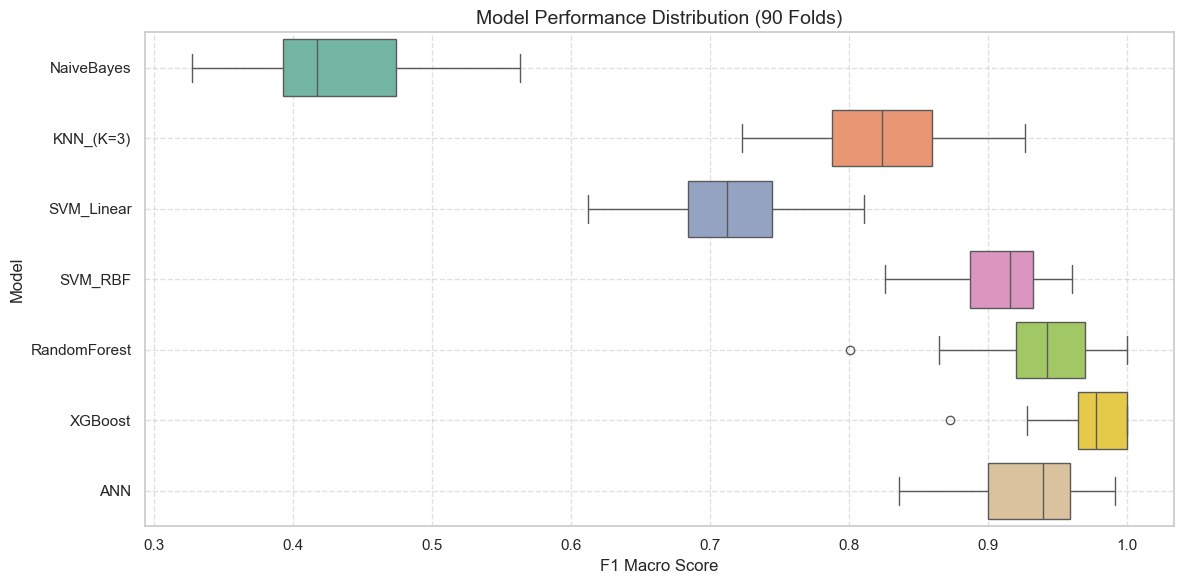

✅ Exact plot saved to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results/pipeline_model_performance_distribution.png


In [41]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup path using pathlib
project_root = Path.cwd().parent 
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# 2. Extract scores from your master_results dictionary
plot_data = []
for model_name, info in master_results.items():
    # cv_results contains the array of 90 scores from your master execution
    f1_scores = info['cv_results']['test_f1_macro'] 
    for score in f1_scores:
        plot_data.append({"Model": model_name, "F1 Macro Score": score})

plot_df = pd.DataFrame(plot_data)

# 3. Visualization (Matching your reference style exactly)
plt.figure(figsize=(12, 6))

# Using 'Set2' palette and 'Model' for hue as in your reference
sns.boxplot(
    x="F1 Macro Score", 
    y="Model", 
    data=plot_df, 
    palette="Set2", 
    hue="Model",
    legend=False # Prevents duplicate legend
)

plt.title("Model Performance Distribution (90 Folds)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6) # Dashed grid as in your reference

# 4. Save and Show
plot_path = results_dir / "pipeline_model_performance_distribution.png"
plt.tight_layout()
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Exact plot saved to: {plot_path}")

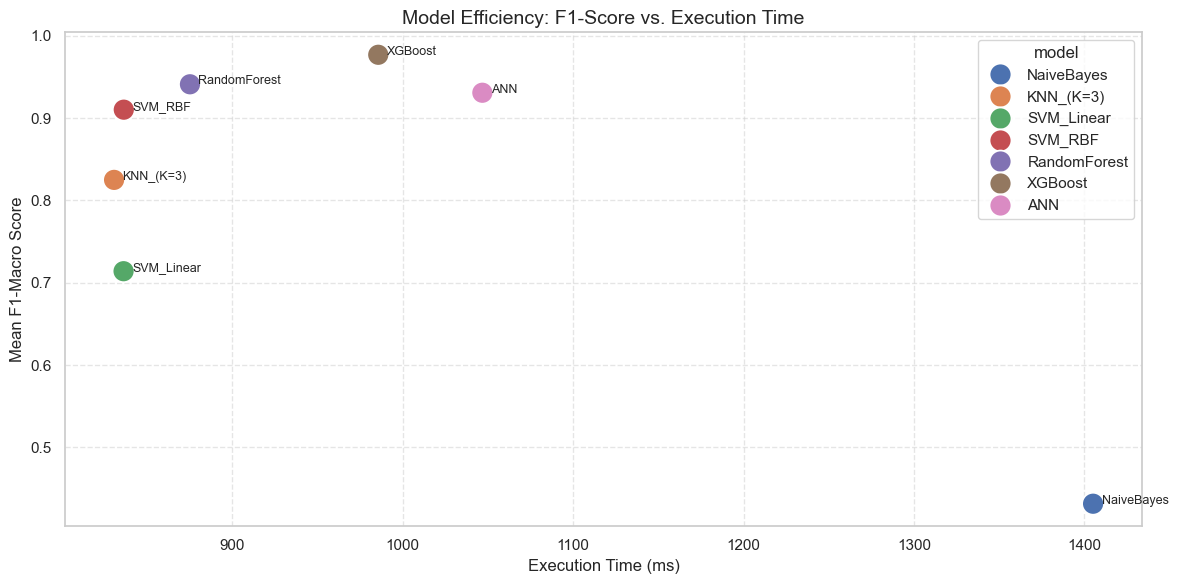

✅ Efficiency Trade-off plot saved to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results/pipeline_model_efficiency_scatter.png


In [42]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Setup paths using pathlib
project_root = Path.cwd().parent 
results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

# 2. Prepare the results_df from master_results
efficiency_data = []
for name, info in master_results.items():
    efficiency_data.append({
        "model": name,
        "time_(ms)": info['time'],
        "f1_mean": info['metrics']['f1']['mean']
    })

# Set model as index to match your reference code's 'hue=results_df.index'
results_df = pd.DataFrame(efficiency_data).set_index("model")

# 3. Visualization
plt.figure(figsize=(12, 6))

# Ensure numeric consistency for plotting
sns.scatterplot(
    data=results_df, 
    x="time_(ms)", 
    y="f1_mean", 
    hue=results_df.index, 
    s=250, 
    legend="full"
)

# Annotate points with model names (matching your reference style)
for idx, row in results_df.iterrows():
    # Adding a small offset (+5) to the x-position for readability
    plt.text(row["time_(ms)"] + 5, row["f1_mean"], idx, fontsize=9, fontweight="medium")

plt.title("Model Efficiency: F1-Score vs. Execution Time", fontsize=14)
plt.xlabel("Execution Time (ms)")
plt.ylabel("Mean F1-Macro Score")
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Save using pathlib
plot_file = results_path / "pipeline_model_efficiency_scatter.png"
plt.tight_layout()
plt.savefig(plot_file, dpi=300)
plt.show()

print(f"✅ Efficiency Trade-off plot saved to: {plot_file}")

## Phase 5: Final Testing & Generalization
---
Before training, we have taken 10% of our dataset out, for the testing. This is unknown data, which haven't been use during training/validation phase.


In [43]:
from pathlib import Path
import pandas as pd
from time import process_time_ns
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

# 1. Setup paths using pathlib
project_root = Path.cwd().parent 
results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

# 2. CRITICAL: Encode y_vault using the existing LabelEncoder 'le'
# Use .transform(), NOT .fit_transform()
y_vault_encoded = le.transform(y_vault)

# 3. Dictionary to hold all final testing metrics
test_results = {}

print("🚀 Finalizing models and recording execution time...")

for name, info in master_results.items():
    print(f"   Testing {name}...")

    # Retrieve the pipeline
    pipeline = info['model_pipeline']

    # Record start time for Final Fit + Predict
    start_time = process_time_ns()

    # Fit on full 90% pool
    pipeline.fit(X_dev, y_dev_encoded)

    # Predict on the 10% unknown Vault data
    y_vault_pred = pipeline.predict(X_vault)

    # Record end time
    end_time = process_time_ns()
    total_time_ms = (end_time - start_time) / 1_000_000

    # Store all metrics
    test_results[name] = {
        "test_f1": f1_score(y_vault_encoded, y_vault_pred, average="macro"),
        "test_accuracy": accuracy_score(y_vault_encoded, y_vault_pred),
        "test_precision": precision_score(y_vault_encoded, y_vault_pred, average="macro", zero_division=0),
        "test_recall": recall_score(y_vault_encoded, y_vault_pred, average="macro", zero_division=0),
        "test_time_ms": total_time_ms,
        "classification_report": classification_report(y_vault_encoded, y_vault_pred),
        "y_pred": y_vault_pred, 
    }

# 4. Create the Master Performance DataFrame
final_metrics = []
for name, metrics in test_results.items():
    final_metrics.append({
        "model": name,
        "test_f1": metrics["test_f1"],
        "test_accuracy": metrics["test_accuracy"],
        "test_precision": metrics["test_precision"],
        "test_recall": metrics["test_recall"],
        "test_time_ms": metrics["test_time_ms"],
    })

df_final_test = pd.DataFrame(final_metrics).sort_values(by="test_f1", ascending=False)
display(df_final_test)

# 4. Save the results
df_final_test.to_csv(results_path / "final_test_metrics_with_time.csv", index=False)

🚀 Finalizing models and recording execution time...
   Testing NaiveBayes...
   Testing KNN_(K=3)...
   Testing SVM_Linear...
   Testing SVM_RBF...
   Testing RandomForest...
   Testing XGBoost...
   Testing ANN...


,model,test_f1,test_accuracy,test_precision,test_recall,test_time_ms
5,XGBoost,1.000000,1.000000,1.000000,1.000000,35810.739210
4,RandomForest,0.973322,0.988439,0.987500,0.962220,279.305824
6,ANN,0.951016,0.976879,0.957895,0.949062,1909.314735
3,SVM_RBF,0.933525,0.947977,0.903747,0.972379,159.310030
1,KNN_(K=3),0.861932,0.936416,0.905142,0.838167,145.857414
2,SVM_Linear,0.714043,0.803468,0.646955,0.850976,289.282176
0,NaiveBayes,0.478588,0.710983,0.613622,0.597581,119.623355


#### 5.2 Comparison: Training vs. Testing
A critical part of our report is checking for overfitting. If a model got 99% in Phase-3 but gets 70% here, it failed to generalize.

In [44]:
from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# 1. Setup paths using pathlib
project_root = Path.cwd().parent 
results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

# 2. Safety Check: Encode y_vault using the existing LabelEncoder 'le'
y_test_encoded = le.transform(y_vault)

# 3. Build the comprehensive comparison dictionary
final_result_comparison = {}

for name, info in master_results.items():
    # Use the predictions we just generated in the previous step
    # Ensure test_results[name]["y_pred"] exists from your previous cell execution
    y_pred = test_results[name]["y_pred"]

    # Calculate Test metrics (snake_case internally, then mapped to your display headers)
    final_result_comparison[name] = {
        # Cross Validation (CV) Results from your training phase
        "f1_cv": info['metrics']['f1']['mean'],
        "f1_test": f1_score(y_test_encoded, y_pred, average="macro"),
        
        "acc_cv": info['metrics']['accuracy']['mean'],
        "acc_test": accuracy_score(y_test_encoded, y_pred),
        
        "prec_cv": info['metrics']['precision']['mean'],
        "prec_test": precision_score(y_test_encoded, y_pred, average="macro", zero_division=0),
        
        "rec_cv": info['metrics']['recall']['mean'],
        "rec_test": recall_score(y_test_encoded, y_pred, average="macro", zero_division=0),
        
        "time_ms": test_results[name]["test_time_ms"]
    }

# 4. Create the Comparison DataFrame
final_comp_df = pd.DataFrame.from_dict(final_result_comparison, orient="index")

# 5. Format and Sort
print("\n--- COMPREHENSIVE METRIC COMPARISON (Cross Validation vs. TEST) ---")
final_comp_df = final_comp_df.sort_values(by="f1_test", ascending=False)

# Display with 4 decimal places for scientific precision
display(final_comp_df.style.format("{:.4f}"))

# 6. Save as CSV for your results folder
final_comp_df.to_csv(results_path / "pipeline_comprehensive_model_comparison.csv")


--- COMPREHENSIVE METRIC COMPARISON (Cross Validation vs. TEST) ---


,f1_cv,f1_test,acc_cv,acc_test,prec_cv,prec_test,rec_cv,rec_test,time_ms
XGBoost,0.9771,1.0000,0.9925,1.0000,0.9797,1.0000,0.9770,1.0000,35810.7392
RandomForest,0.9412,0.9733,0.9746,0.9884,0.9382,0.9875,0.9507,0.9622,279.3058
ANN,0.9309,0.9510,0.9623,0.9769,0.9348,0.9579,0.9328,0.9491,1909.3147
SVM_RBF,0.9103,0.9335,0.9270,0.9480,0.8800,0.9037,0.9550,0.9724,159.3100
KNN_(K=3),0.8250,0.8619,0.9272,0.9364,0.8621,0.9051,0.8155,0.8382,145.8574
SVM_Linear,0.7140,0.7140,0.7873,0.8035,0.6542,0.6470,0.8479,0.8510,289.2822
NaiveBayes,0.4314,0.4786,0.6955,0.7110,0.5432,0.6136,0.5617,0.5976,119.6234


#### Plot Comparisons all metrics

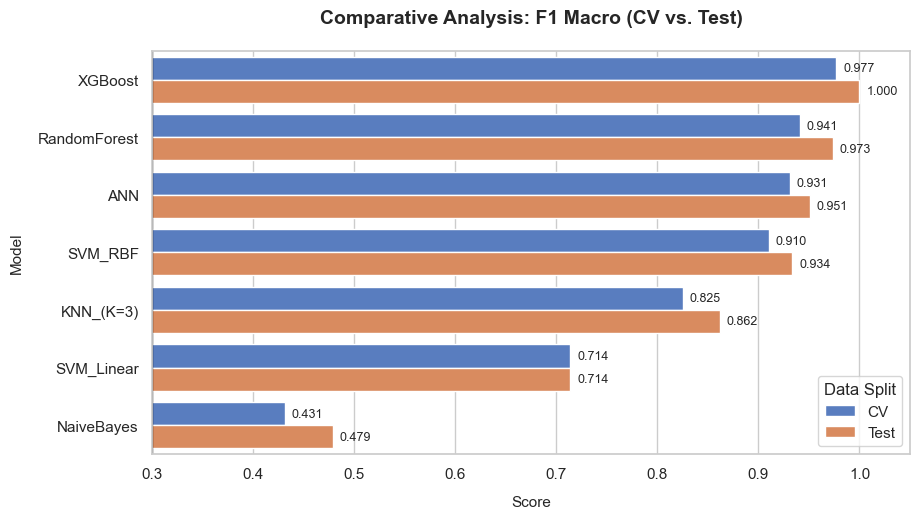

✅ Successfully saved: comparison_f1.png


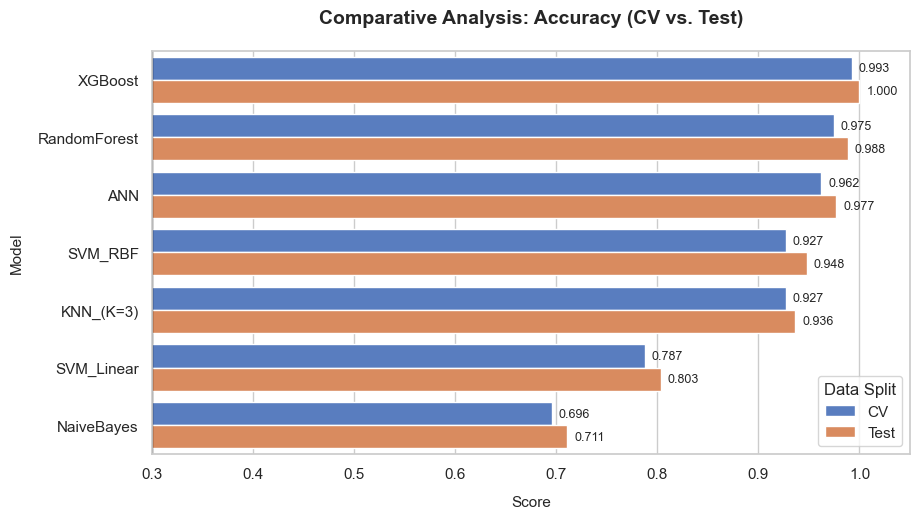

✅ Successfully saved: comparison_acc.png


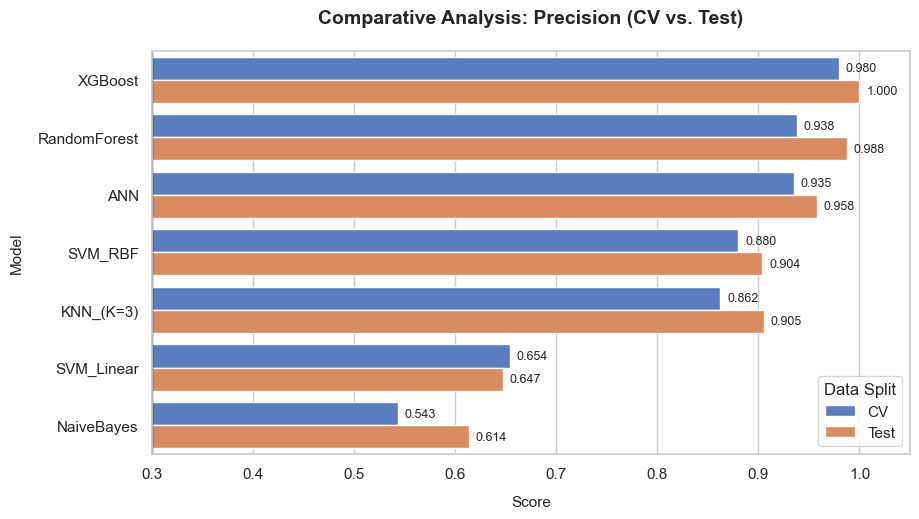

✅ Successfully saved: comparison_prec.png


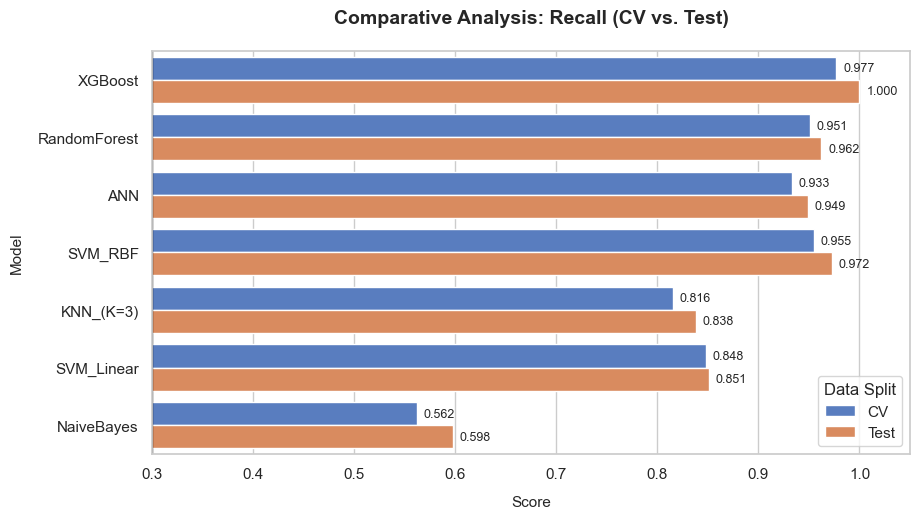

✅ Successfully saved: comparison_rec.png


In [45]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup paths
project_root = Path.cwd().parent 
results_path = project_root / "results"
results_path.mkdir(parents=True, exist_ok=True)

# 2. Metric mapping
metric_map = {
    "f1": "F1 Macro",
    "acc": "Accuracy",
    "prec": "Precision",
    "rec": "Recall"
}

# 3. Model order based on F1_Test for consistency across all charts
model_order = final_comp_df.sort_values(by="f1_test", ascending=False).index.tolist()

sns.set_theme(style="whitegrid")

# 4. Loop to create and save each plot individually
for key, display_name in metric_map.items():
    # Create a fresh figure for each metric
    plt.figure(figsize=(10, 6))
    
    # Reshape data for this specific metric
    plot_df = final_comp_df[[f"{key}_cv", f"{key}_test"]].copy()
    plot_df.columns = ["CV", "Test"]
    plot_df = plot_df.reset_index().rename(columns={"index": "Model"})
    plot_df = plot_df.melt(id_vars="Model", var_name="Type", value_name="Score")

    # Create the horizontal barplot
    ax = sns.barplot(
        data=plot_df, 
        x="Score", 
        y="Model", 
        hue="Type", 
        order=model_order, 
        palette="muted"
    )

    # Formatting with padding
    plt.title(f"Comparative Analysis: {display_name} (CV vs. Test)", fontsize=14, fontweight="bold", pad=20)
    plt.xlabel("Score", fontsize=11, labelpad=10)
    plt.ylabel("Model", fontsize=11, labelpad=10)
    plt.xlim(0.3, 1.05) # Emphasize performance differences
    plt.axvline(0.3, color='black', linewidth=1, alpha=0.7)
    
    # Legend and Bar Labels
    plt.legend(title="Data Split", loc='lower right', frameon=True)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=5, fontsize=9)

    # Add extra padding around the layout
    plt.tight_layout(pad=3.0)

    # 5. Save using pathlib
    file_name = f"comparison_{key}.png"
    save_path = results_path / file_name
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Successfully saved: {file_name}")

### Confusion Matrix, ROC Curve

🚀 Exporting diagnostic cards to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a2_classification/mcda5580-data-mining-a2-classification/results


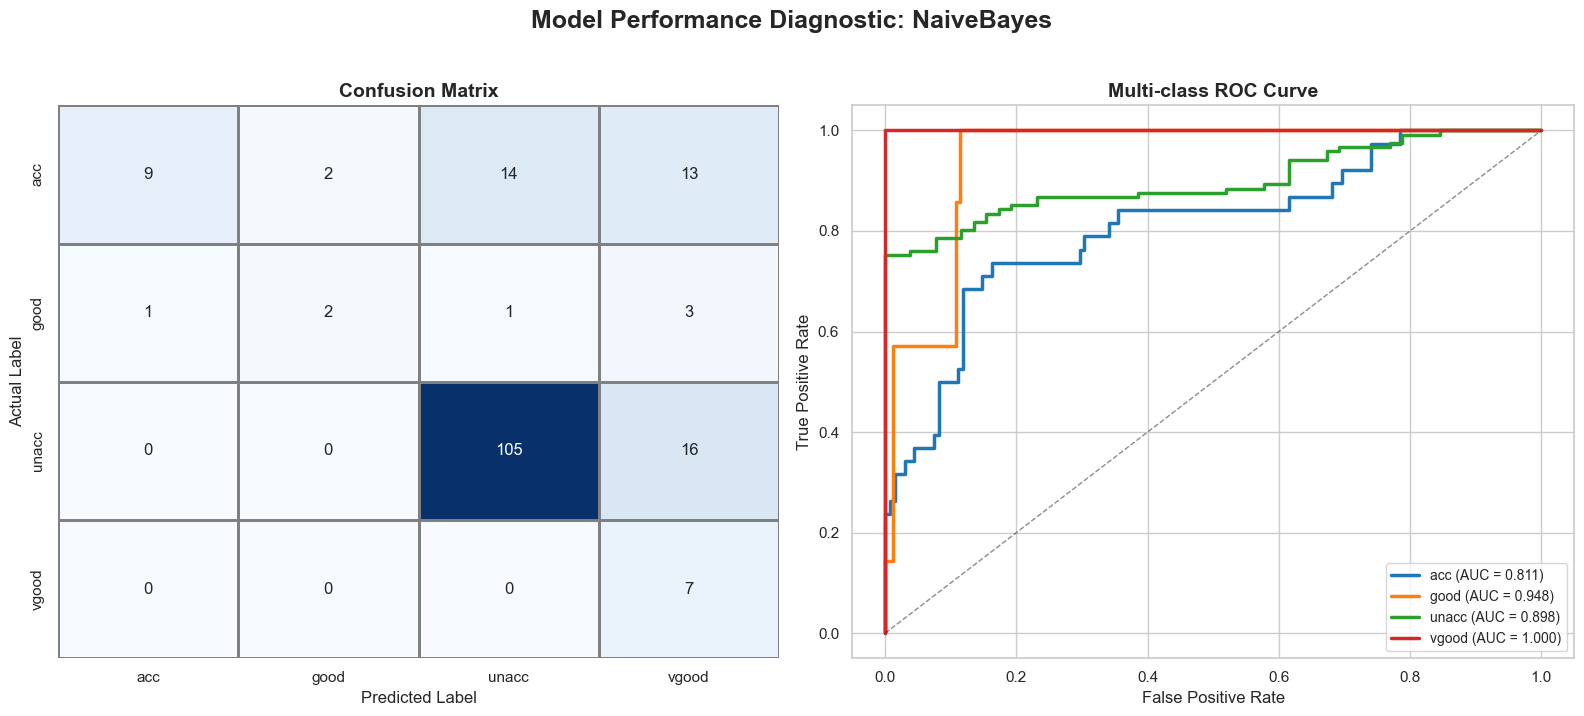

   Successfully saved: pipeline_diagnostic_NaiveBayes.png


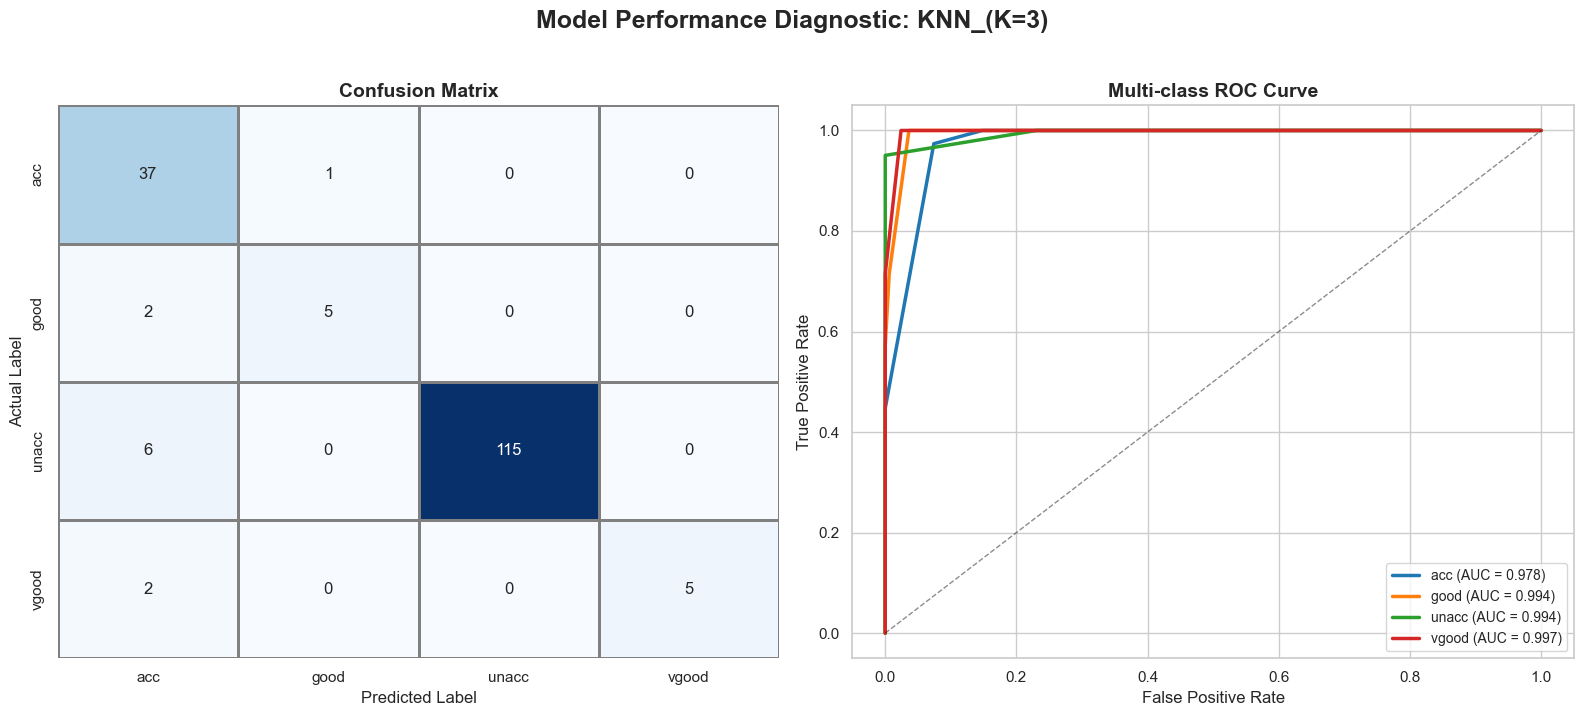

   Successfully saved: pipeline_diagnostic_KNN_K3.png


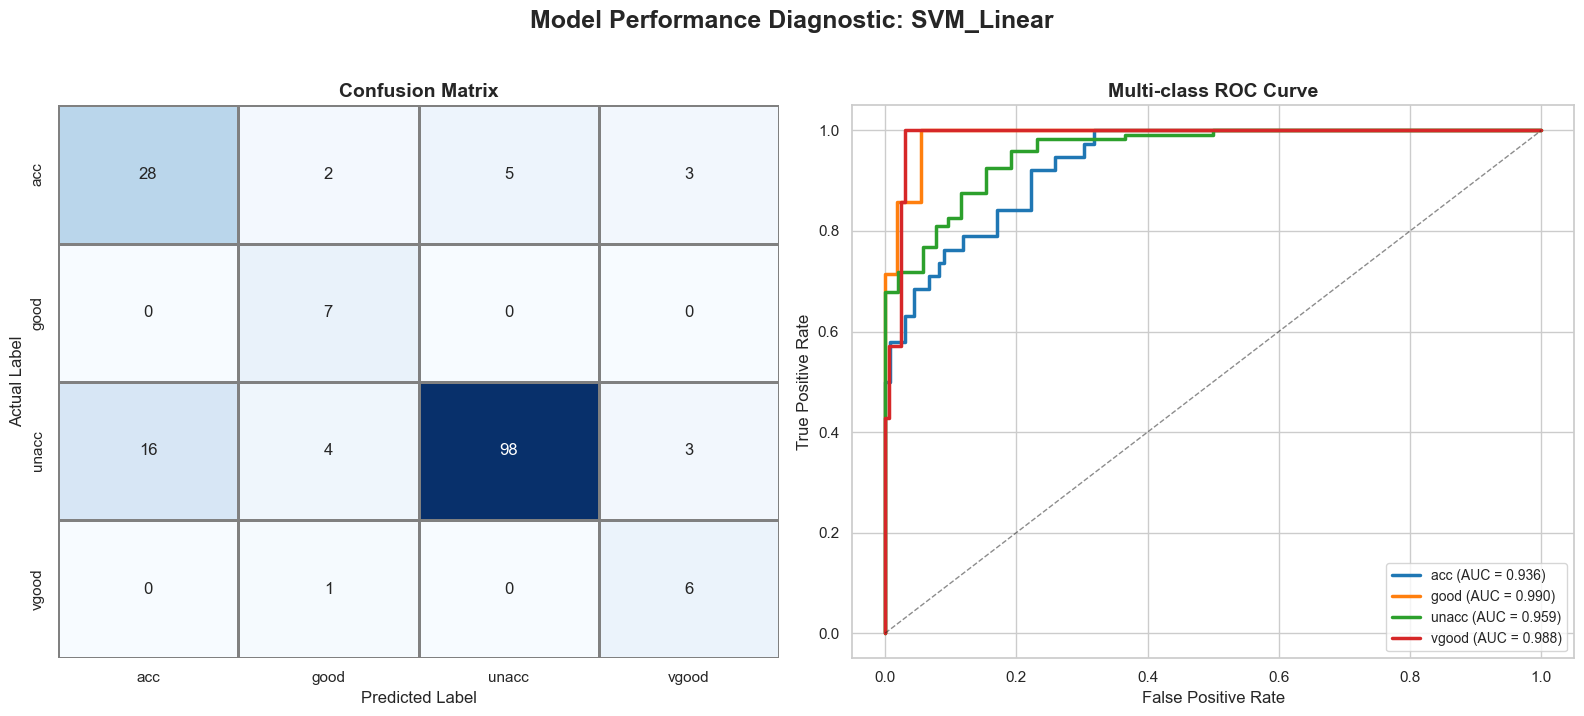

   Successfully saved: pipeline_diagnostic_SVM_Linear.png


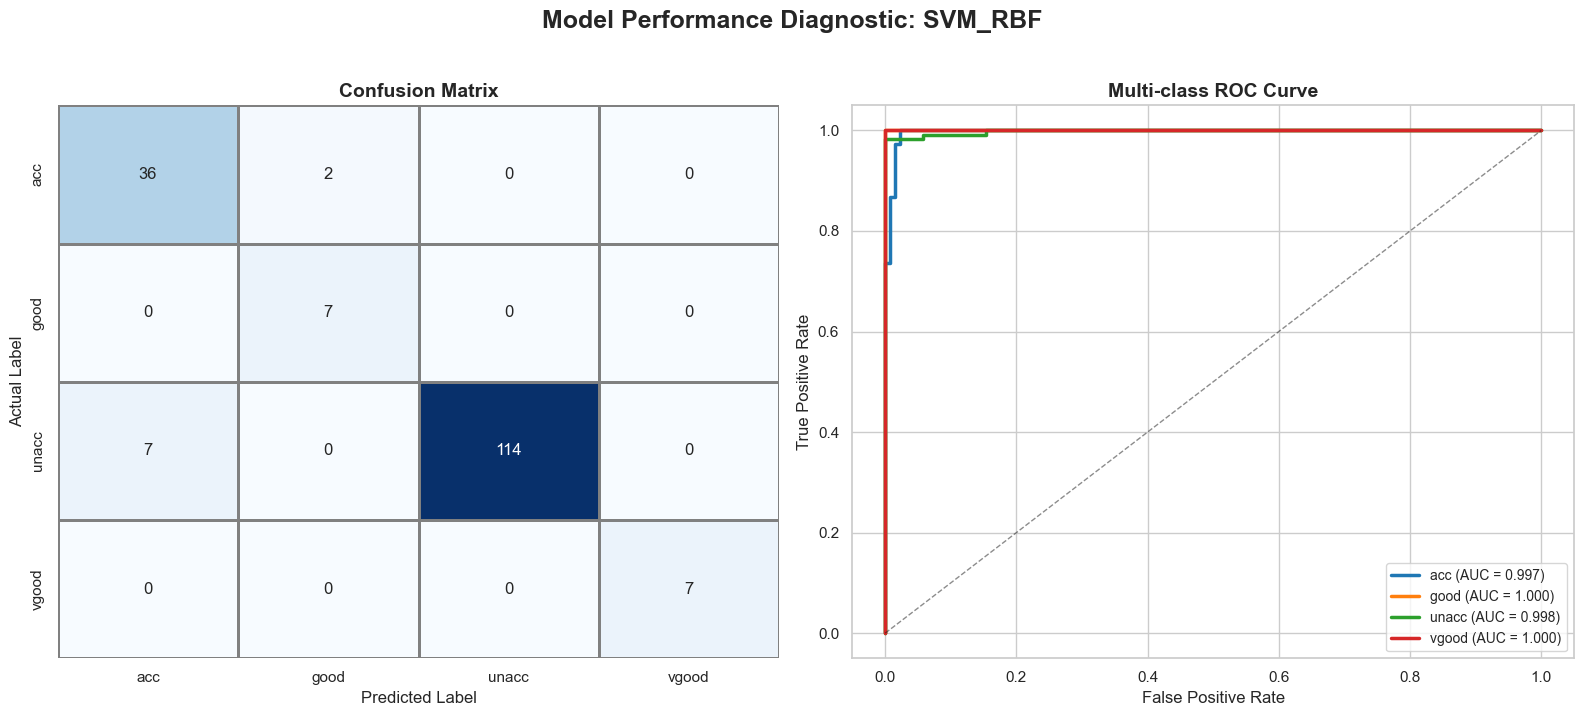

   Successfully saved: pipeline_diagnostic_SVM_RBF.png


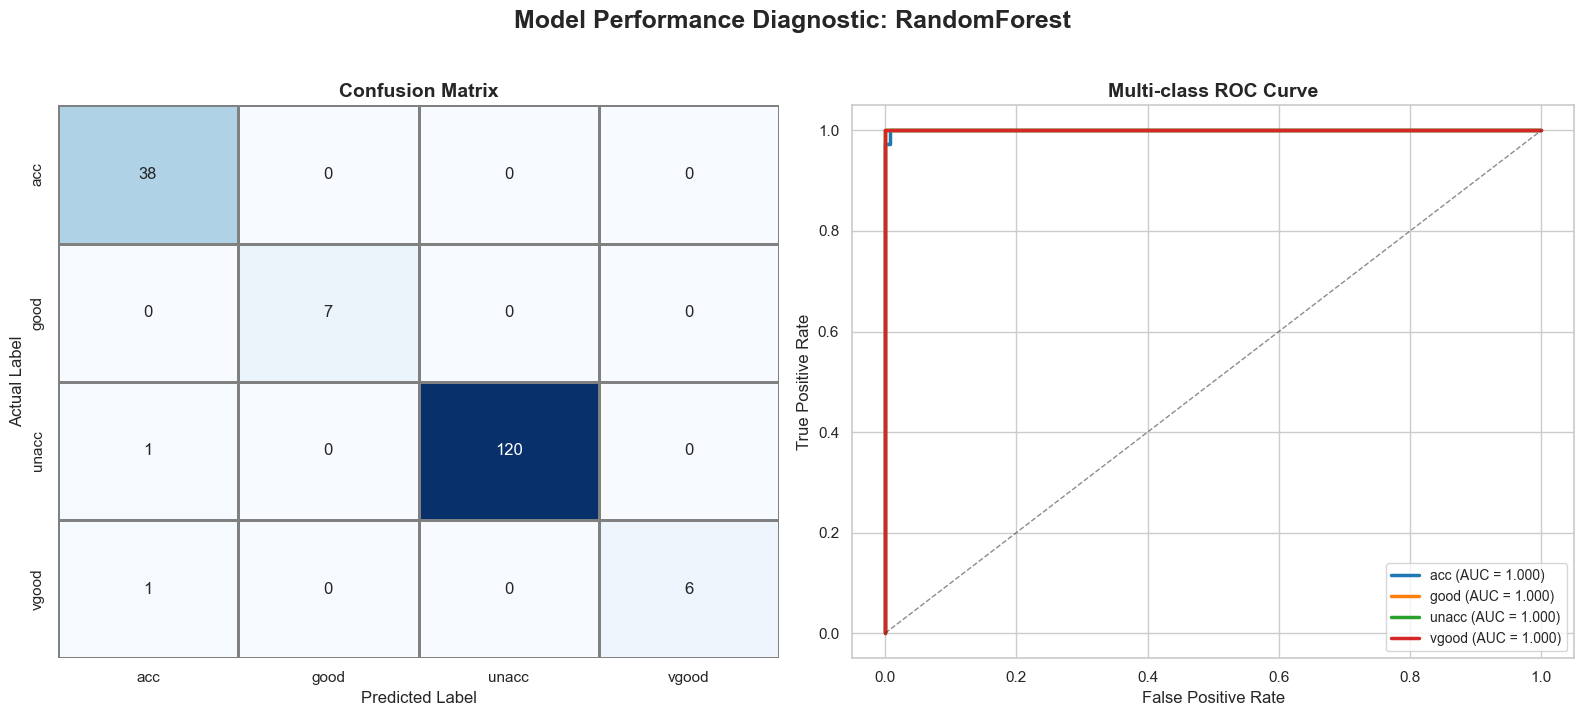

   Successfully saved: pipeline_diagnostic_RandomForest.png


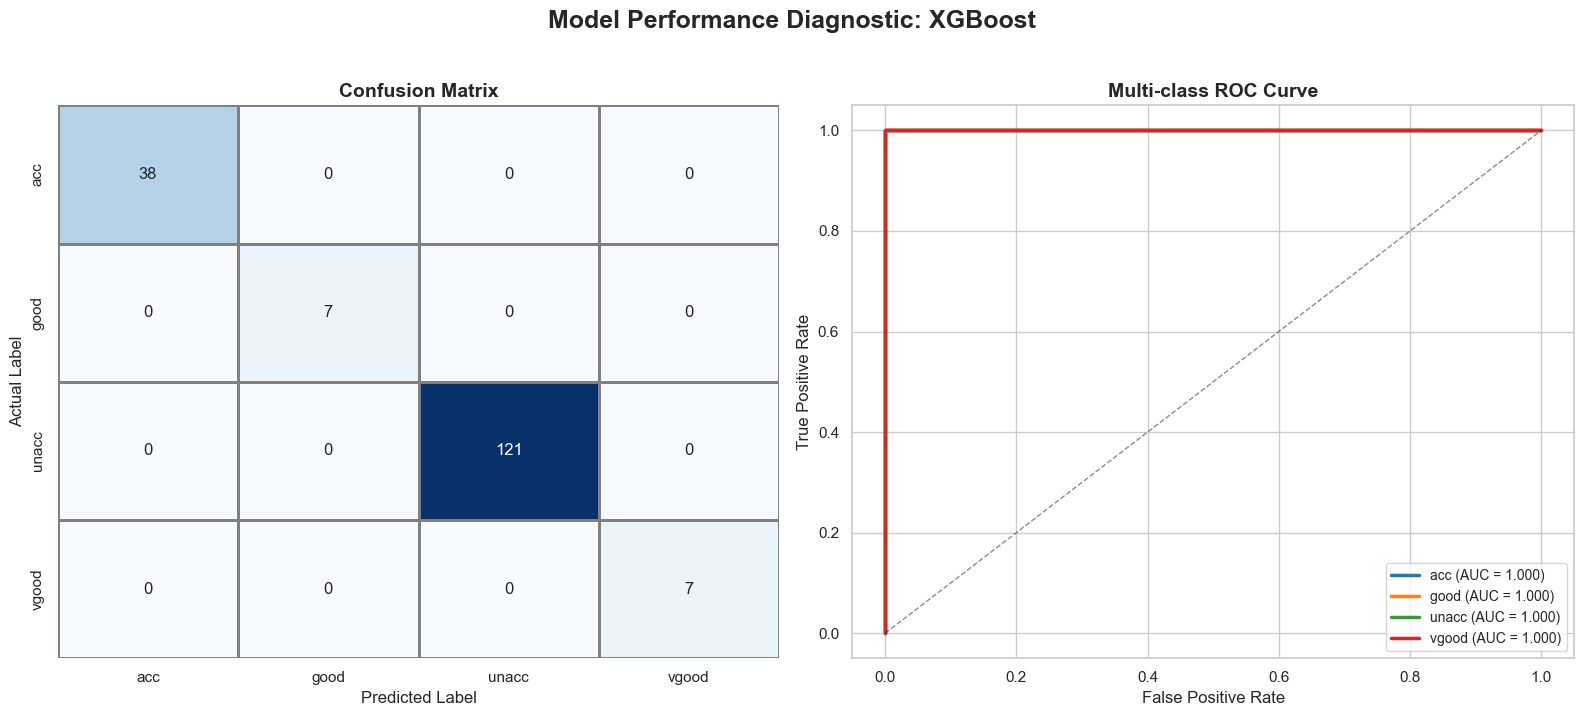

   Successfully saved: pipeline_diagnostic_XGBoost.png


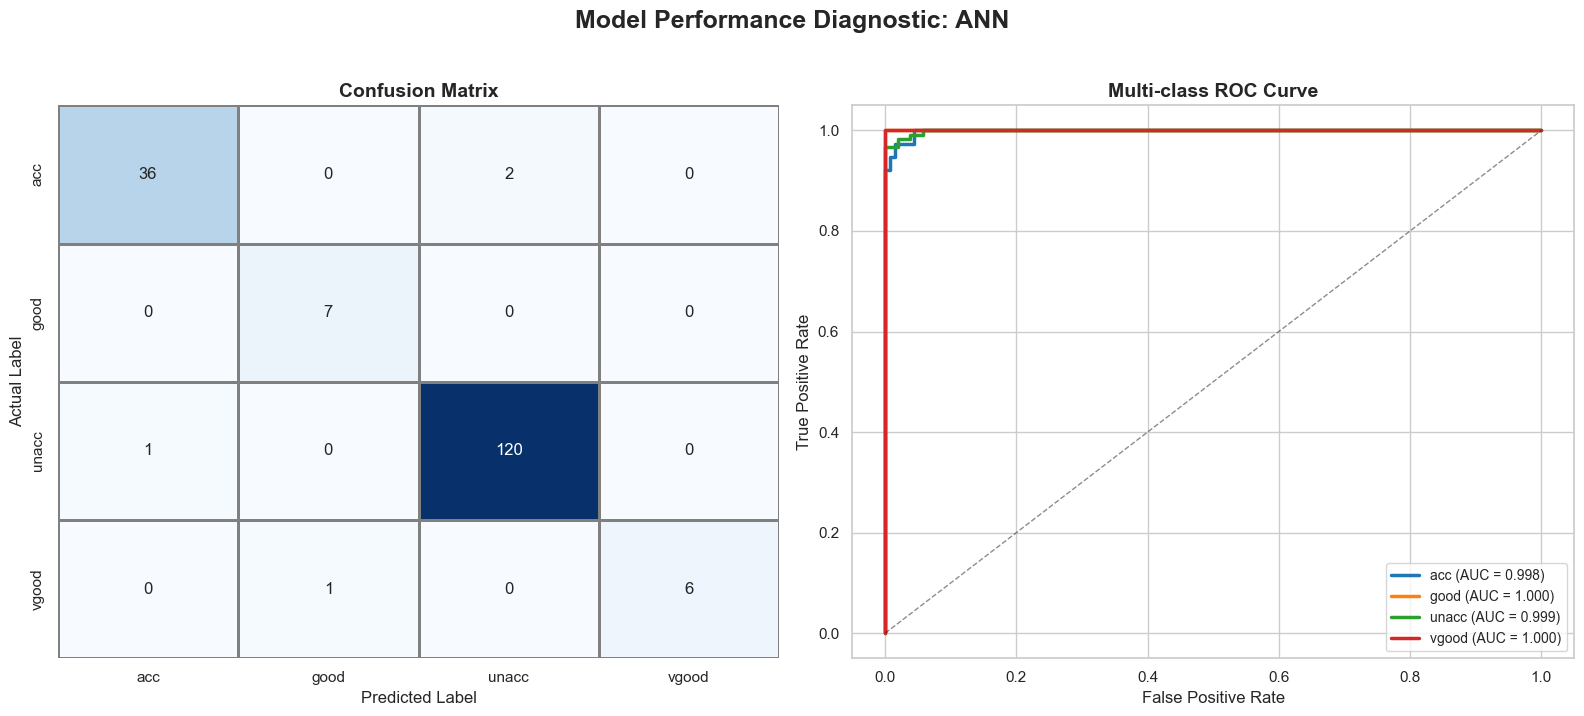

   Successfully saved: pipeline_diagnostic_ANN.png

✅ All diagnostics have been exported to the results directory.


In [46]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup the directory path
# Consistent with your project structure: sibling of 'code'
results_dir = Path.cwd().parent / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Data setup
# 'le.classes_' provides the original string names in the correct integer order
class_names = le.classes_ 
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2, 3])

print(f"🚀 Exporting diagnostic cards to: {results_dir}")

# 2. Loop through each model to create individual diagnostic cards
for name, model_info in test_results.items():
    # Create a fresh figure for each model
    fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(16, 7))
    plt.subplots_adjust(wspace=0.3)

    # Use the fitted pipeline from your master_results
    # This ensures X_vault is cleaned/scaled correctly before prediction
    pipeline = master_results[name]["model_pipeline"]
    y_pred = model_info["y_pred"]
    y_score = pipeline.predict_proba(X_vault)

    # --- A. Confusion Matrix (Left) ---
    # Highlights exactly which car classes are being misidentified
    cm = confusion_matrix(y_test_encoded, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax_cm,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
        linewidths=1,
        linecolor="gray",
    )
    ax_cm.set_title(f"Confusion Matrix", fontsize=14, fontweight="bold")
    ax_cm.set_ylabel("Actual Label")
    ax_cm.set_xlabel("Predicted Label")

    # --- B. ROC Curve (Right) ---
    # Visualizes the True Positive vs False Positive trade-off per class
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
    for i, color in zip(range(len(class_names)), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=color, lw=2.5, label=f"{class_names[i]} (AUC = {roc_auc:.3f})")

    ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax_roc.set_title(f"Multi-class ROC Curve", fontsize=14, fontweight="bold")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend(loc="lower right", fontsize=10)

    # Styling the overall card
    fig.suptitle(f"Model Performance Diagnostic: {name}", fontsize=18, fontweight="bold", y=1.02)
    plt.tight_layout()

    # 3. Save the result
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
    save_path = results_dir / f"pipeline_diagnostic_{clean_name}.png"

    # Save BEFORE show to avoid clearing the figure buffer
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig) 
    print(f"   Successfully saved: {save_path.name}")

print("\n✅ All diagnostics have been exported to the results directory.")